In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://rilianx@github.com/rilianx/CPMP-ML.git

Cloning into 'CPMP-ML'...
remote: Enumerating objects: 1830, done.
remote: Counting objects: 100% (249/249), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 1830 (delta 102), reused 232 (delta 89), pack-reused 1581
Receiving objects: 100% (1830/1830), 6.69 MiB | 4.68 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [3]:
!git clone -b Dinamic_CPMP https://github.com/LosWillyAmigos/CPMP_With_attention.git

Cloning into 'CPMP_With_attention'...
remote: Enumerating objects: 575, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 575 (delta 49), reused 35 (delta 31), pack-reused 488
Receiving objects: 100% (575/575), 39.78 MiB | 13.46 MiB/s, done.
Resolving deltas: 100% (277/277), done.


In [4]:
import matplotlib.pyplot as plt
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [5]:
%cd CPMP_With_attention
from CPMP_MODEL.Model_cpmp import create_model,save_model,load_model
from data_json import load_data_from_json
%cd ..
from CPMP_MODEL.Evaluate_model import cosine_Similarity, evaluate

/content/CPMP_With_attention
/content


In [6]:
model = create_model(heads=5,H=5,optimizer='Adam')

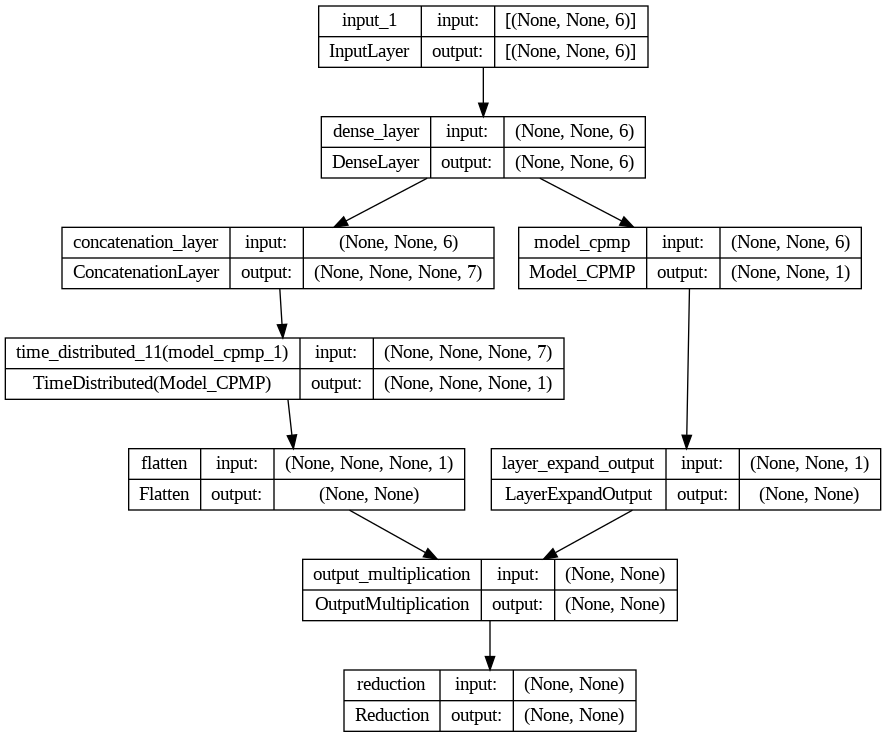

In [7]:
plot_model(model,show_shapes=True,show_layer_names=True)

In [8]:
states, labels = load_data_from_json(name_file="/content/drive/MyDrive/data_5x5_v2")

In [9]:
X_train, X_test, y_train, y_test = train_test_split(states, labels, test_size=0.2, random_state=42)

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((200000, 5, 6), (50000, 5, 6), (200000, 20), (50000, 20))

In [11]:
records = model.fit(x=X_train,y=y_train,batch_size=32,epochs=30)

Epoch 1/30
6250/6250 [==============================] - 333s 51ms/step - loss: 0.3490 - mae: 0.1997 - mse: 0.0992
Epoch 2/30
6250/6250 [==============================] - 320s 51ms/step - loss: 0.3233 - mae: 0.1889 - mse: 0.0943
Epoch 3/30
6250/6250 [==============================] - 324s 52ms/step - loss: 0.3145 - mae: 0.1851 - mse: 0.0926
Epoch 4/30
6250/6250 [==============================] - 329s 53ms/step - loss: 0.2810 - mae: 0.1715 - mse: 0.0858
Epoch 5/30
6250/6250 [==============================] - 352s 56ms/step - loss: 0.2766 - mae: 0.1698 - mse: 0.0848
Epoch 6/30
6250/6250 [==============================] - 357s 57ms/step - loss: 0.2705 - mae: 0.1662 - mse: 0.0829
Epoch 7/30
6250/6250 [==============================] - 337s 54ms/step - loss: 0.2661 - mae: 0.1636 - mse: 0.0815
Epoch 8/30
6250/6250 [==============================] - 312s 50ms/step - loss: 0.2634 - mae: 0.1621 - mse: 0.0808
Epoch 9/30
6250/6250 [==============================] - 319s 51ms/step - loss: 0.2617 - 

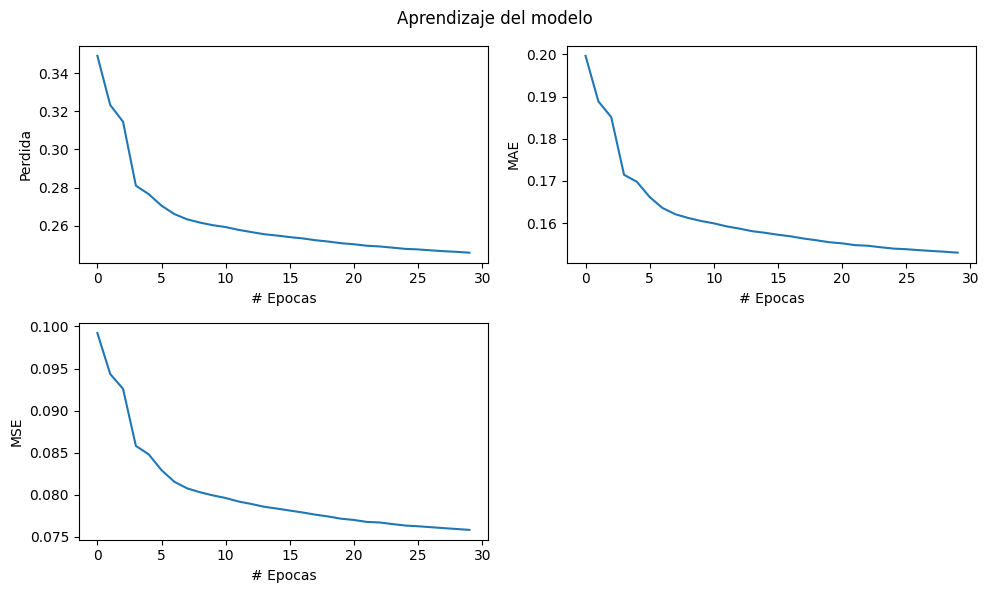

In [12]:
plt.figure(figsize= (10, 6))

plt.subplot(2, 2, 1)
plt.xlabel("# Epocas")
plt.ylabel("Perdida")
plt.plot(records.history['loss'])

plt.subplot(2, 2, 2)
plt.xlabel("# Epocas")
plt.ylabel("MAE")
plt.plot(records.history['mae'])

plt.subplot(2, 2, 3)
plt.xlabel("# Epocas")
plt.ylabel("MSE")
plt.plot(records.history['mse'])

plt.suptitle('Aprendizaje del modelo')
plt.tight_layout()
plt.show()

In [13]:
predict = model.predict(X_test)

1563/1563 [==============================] - 13s 7ms/step


In [ ]:
results_1 = cosine_Similarity(predict, y_test)
results_2 = mean_absolute_error(y_test, predict)
results_3 = mean_squared_error(y_test, predict)

print(f'Precisión del modelo: {round(results_1 * 100, 3)}%')
print(f'Error Absoluto Medio: {round(results_2 * 100, 3)}%')
print(f'Error cuadratico medio: {round(results_3 * 100, 3)}%')

In [ ]:
model.summary()

In [16]:
evaluate(model=model, sample_size=200, S=5, H=5, N=15)

iter: 1
iter: 2
iter: 3
iter: 4
iter: 5
iter: 6
iter: 7
iter: 8
iter: 9
iter: 10
iter: 11
iter: 12
iter: 13
iter: 14
iter: 15
iter: 16
iter: 17
iter: 18
iter: 19
iter: 20
iter: 21
iter: 22
iter: 23
iter: 24
iter: 25
iter: 26
iter: 27
iter: 28
iter: 29
iter: 30
iter: 31
iter: 32
iter: 33
iter: 34
iter: 35
iter: 36
iter: 37
iter: 38
iter: 39
iter: 40
iter: 41
iter: 42
iter: 43
iter: 44
iter: 45
iter: 46
iter: 47
iter: 48
iter: 49
iter: 50
iter: 51
iter: 52
iter: 53
iter: 54
iter: 55
iter: 56
iter: 57
iter: 58
iter: 59
iter: 60
iter: 61
iter: 62
iter: 63
iter: 64
iter: 65
iter: 66
iter: 67
iter: 68
iter: 69
iter: 70
iter: 71
iter: 72
iter: 73
iter: 74
iter: 75
iter: 76
iter: 77
iter: 78
iter: 79
iter: 80
iter: 81
iter: 82
iter: 83
iter: 84
iter: 85
iter: 86
iter: 87
iter: 88
iter: 89
iter: 90
iter: 91
iter: 92
iter: 93
iter: 94
iter: 95
iter: 96
iter: 97
iter: 98
iter: 99
iter: 100
iter: 101
iter: 102
iter: 103
iter: 104
iter: 105
iter: 106
iter: 107
iter: 108
iter: 109
iter: 110
iter: 11

In [17]:
save_model(name='Model_5x5.h5', model=model)

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


True